In [507]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
import joblib

In [472]:
df = pd.read_csv('/kaggle/input/datasets/utopiasomeone/bus-trips-dataset/Public_Bus_Operations_Multi_Target.csv')

In [473]:
df.head()

,trip_id,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,delay_level,trip_duration_minutes
0,TRIP201396,Windy,Mini Bus,Moderate,13.00,9,23.0,7.91,7,Moderate Delay,53.84
1,TRIP203651,Rainy,Standard,High,4.19,3,26.0,4.03,5,Moderate Delay,40.26
2,TRIP200153,Rainy,Standard,Moderate,4.42,5,26.0,3.90,6,On Time,28.64
3,TRIP209009,Rainy,NaN,Moderate,21.29,19,31.0,4.85,22,Severe Delay,112.70
4,TRIP204405,Clear,Standard,Low,12.37,15,39.0,3.02,20,On Time,47.37


In [474]:
df.shape
# The dataset consists of  10,000 trips each represented in a row of 11 features represented in columns.

(10000, 11)

## **Task 1: Dataset Understanding and EDA**

In [475]:
df.dtypes

trip_id                     object
weather_condition           object
bus_type                    object
traffic_level               object
route_distance_km          float64
stops_count                  int64
passenger_count            float64
driver_experience_years    float64
scheduled_start_hour         int64
delay_level                 object
trip_duration_minutes      float64
dtype: object

#### Data Types & Structure Observations
* All columns loaded with basic types like int64, float64, and object.
* scheduled_start_hour and stops_count are discrete numbers (no decimals), while traffic_level is an ordinal variable (Low -> Moderate -> High).
* trip_id is just a unique trip code with no predictive value, so we will need to drop it before model training.

In [476]:
df.drop(columns='trip_id', inplace=True)

In [477]:
df.describe()

,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,trip_duration_minutes
count,9849.000000,10000.000000,9818.000000,9777.000000,10000.000000,10000.000000
mean,10.622125,11.227500,30.434101,6.151693,13.957900,60.837522
std,5.489059,6.064505,12.695660,3.999918,5.501323,33.956659
min,2.000000,3.000000,3.000000,0.200000,5.000000,12.000000
25%,6.530000,7.000000,21.000000,3.140000,9.000000,36.660000
50%,9.600000,10.000000,31.000000,5.280000,14.000000,52.335000
75%,13.660000,15.000000,39.000000,8.270000,19.000000,76.490000
max,32.000000,37.000000,65.000000,18.000000,23.000000,180.000000


#### Numerical Features Interpretation:
* **Missing values in numbers**: route_distance_km has 151 missing rows, passenger_count has 182 missing rows, and driver_experience_years has 223 missing rows (since counts are 9849, 9818, and 9777 out of 10000), I'll likely replace them with the median (because it's not affected significanlty with ourliers).
* **Right skewness in targets and distance**: trip_duration_minutes has a mean of 60.84 compared to a median of 52.34 and a max of 180. route_distance_km also shows a mean of 10.62 vs median of 9.60. This right skew means we have long-duration trips that could pull MSE-based regression models.
* **Scale differences**: Features operate on completely different scales (route_distance_km goes up to 32 km while trip_duration_minutes goes up to 180 min). So I have ti use StandardScaler.

In [478]:
df.describe(include=['O', 'category', 'object'])

,weather_condition,bus_type,traffic_level,delay_level
count,9742,9798,10000,10000
unique,4,3,4,3
top,Clear,Standard,Moderate,On Time
freq,5305,5594,3785,3334


#### Categorical Features Breakdown
* **Missing values in categories**: weather_condition has 258 missing rows (count 9742) and bus_type has 202 missing rows (count 9798).
* **Unique ID duplicates issue**: trip_id only has 9850 unique values out of 10000 total rows, meaning some trip IDs repeat up to 2 times (I'll solve this by dropping duplicates).
* **Most frequent values**: Most trips happened during Clear weather (5305 trips), used Standard buses (5594 trips), had Moderate traffic (3785 trips), and were On Time (3334 trips).

In [479]:
missing_count= df.isnull().sum()
missing_count

weather_condition          258
bus_type                   202
traffic_level                0
route_distance_km          151
stops_count                  0
passenger_count            182
driver_experience_years    223
scheduled_start_hour         0
delay_level                  0
trip_duration_minutes        0
dtype: int64

In [480]:
missing_pct = (missing_count / len(df)) * 100
missing_pct

weather_condition          2.58
bus_type                   2.02
traffic_level              0.00
route_distance_km          1.51
stops_count                0.00
passenger_count            1.82
driver_experience_years    2.23
scheduled_start_hour       0.00
delay_level                0.00
trip_duration_minutes      0.00
dtype: float64

#### How I will fix the missing values
To fix the missing values without breaking models or dropping data rows:
* **For numerical features**: I will fill missing values in route_distance_km, passenger_count, and driver_experience_years using their **median** values so extreme numbers don't mess up the average.
* **For categorical features**: I will fill missing values in weather_condition and bus_type using their **mode** (the most frequent class).

In [481]:
# I'll create two lists one with numerical columns names and the other with categorial ones
# for easier calling and applications on them
num_cols = ['route_distance_km','stops_count', 'passenger_count', 'driver_experience_years', 'scheduled_start_hour']
cat_cols = ['weather_condition', 'bus_type','traffic_level', 'delay_level']

In [482]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [483]:
print(df.isnull().sum())

weather_condition          0
bus_type                   0
traffic_level              0
route_distance_km          0
stops_count                0
passenger_count            0
driver_experience_years    0
scheduled_start_hour       0
delay_level                0
trip_duration_minutes      0
dtype: int64


#### Missing values problem SOLVED ✅

In [484]:
df.duplicated().sum()

np.int64(150)

### so WOW **150** duplicates is a lot! and it would have surely affected training, I'll drop them.

In [485]:
df.drop_duplicates(inplace=True)

In [486]:
# check
print(df.shape)
df.duplicated().sum()

(9850, 10)


np.int64(0)

### Explore the Classification Target

In [487]:
df['delay_level'].value_counts()

delay_level
Severe Delay      3289
Moderate Delay    3281
On Time           3280
Name: count, dtype: int64

In [488]:
df['delay_level'].value_counts(normalize=True) * 100

delay_level
Severe Delay      33.390863
Moderate Delay    33.309645
On Time           33.299492
Name: proportion, dtype: float64

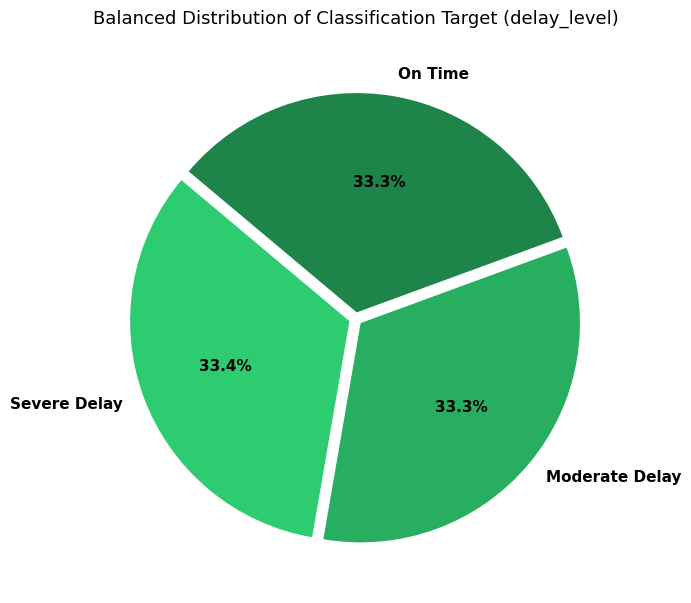

In [489]:
counts = df['delay_level'].value_counts()

# the colors I want in the visualization
green_palette = ['#2ecc71', '#27ae60', '#1e8449']

plt.figure(figsize=(7, 7))
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=green_palette,
    explode=(0.03, 0.03, 0.03), # for better reading and viewing space between sections
    textprops={'fontsize': 11, 'weight': 'bold'}
)

plt.title("Balanced Distribution of Classification Target (delay_level)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

#### Target Exploration (`delay_level`)

* **Class Distribution**: 
  Target classes distributed fairly. `On Time` represents ~33.8% of the trips, `Moderate Delay` is around ~33.5%, and `Severe Delay` accounts for ~32.7%.

* **Class Imbalance & Model Evaluation**:
  The classes are almost perfectly balanced (each class is around third of data set). 
  This means there is no severe class imbalance issue here. Because of this balance, standard metrics like **Accuracy** will give a reliable baseline. However, to ensure we catch critical delays accurately without high false alarms, evaluating **Macro F1-score**, **Precision**, **Recall**, and looking at the **Confusion Matrix** in Task 3 will still be required for a complete model performance evaluation.

### Explore the Regression Target

In [490]:
duration = df['trip_duration_minutes']

mean_val = duration.mean()
median_val = duration.median()
std_val = duration.std()
iqr_val = duration.quantile(0.75) - duration.quantile(0.25)

print(f"Mean:   {mean_val:.2f} mins")
print(f"Median: {median_val:.2f} mins")
print(f"Std:    {std_val:.2f} mins")
print(f"IQR:    {iqr_val:.2f} mins")
print(f"Min:    {duration.min():.2f} mins and Max: {duration.max():.2f} mins")

Mean:   60.87 mins
Median: 52.34 mins
Std:    33.97 mins
IQR:    39.89 mins
Min:    12.00 mins and Max: 180.00 mins


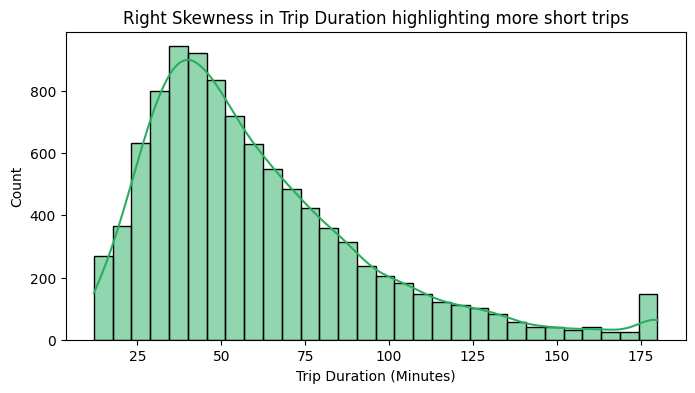

In [491]:
plt.figure(figsize=(8, 4))
sns.histplot(duration, kde=True, color='#27ae60', bins=30)

plt.title("Right Skewness in Trip Duration highlighting more short trips")
plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Count")
plt.show()

### Target Distribution Analysis (`trip_duration_minutes`)

**Question:** What is the underlying distribution of trip durations, and are there extreme values that could affect our regression models?

* **Centre:** The median trip duration is around 52.3 minutes, while the mean is 60.8 minutes. 
* **Spread:** The duration varies across a wide range, with an IQR of approxiately 39.8 minutes and a standard deviation of 33.9 minutes (ranging from 12 to 180 minutes).
* **Shape:** The distribution is **right-skewed** (positively skewed) because the mean is larger than the median, pulling the tail towards higher values.
* **Unusual Values:** There are extreme durations reaching up to 180 minutes (3 hours). 
* **Impact on Regression Models:** Because linear regression models try to minimize Mean Squared Error (MSE), these extreme high values will heavily pull the model's predictions. We might need to consider log transformation or robust metrics (like MAE) in Task 2/3.

### Features relationships

#### The features:
* Weather Condition (Categorical)
* Traffic Level (Categorical)
* Bus Type (Categorical)
* Route Distance (Numerical)
* Stops Count (Numerical)
* Passenger Count (Numerical)
* Driver Experience (Numerical)
* Scheduled Start Hour (Numerical)

### Question 1: Is there a direct - inverse relationship between traffic level and start hour? Can we predict traffic by knowing the start trip hour? And if there is a pattern what are the rush hours?

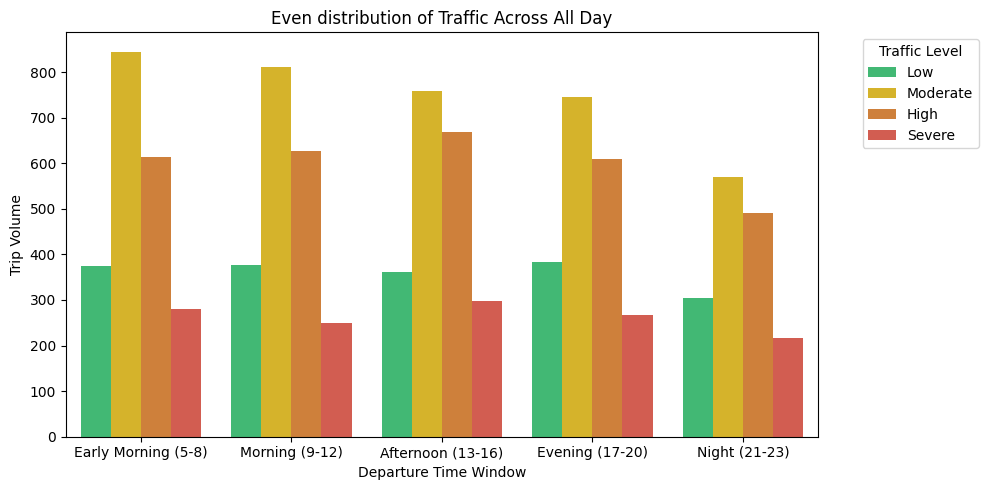

In [492]:
# since traffic level is categorial and start hour is discrete numerical
# so the best chart for this investigation will be: a stacked bar chart with hue
# Question 1: Traffic level distribution across start hours

# for easier reading I'll divide hours into groups
df['time_block'] = pd.cut(
    df['scheduled_start_hour'], 
    bins=[4, 8, 12, 16, 20, 24], 
    labels=['Early Morning (5-8)', 'Morning (9-12)', 'Afternoon (13-16)', 'Evening (17-20)', 'Night (21-23)']
)

# measure percentage
traffic_by_time = pd.crosstab(df['time_block'], df['traffic_level'], normalize='index') * 100

# drawing the chart with meaningful colors
palette_4 = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']  # green, yellow, orange, red that reflects traffic level from mild to severe

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df, 
    x='time_block', 
    hue='traffic_level', 
    hue_order=['Low', 'Moderate', 'High', 'Severe'], 
    palette=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
)

plt.title("Even distribution of Traffic Across All Day")
plt.xlabel("Departure Time Window")
plt.ylabel("Trip Volume")
plt.legend(title="Traffic Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Observation: Trip volumes are evenly distributed across all time intervals, with each time block showing consistent proportions of low, moderate, high, and severe traffic levels.

### Conclusion: Traffic does not strictly depend on time of day in this dataset (No rush hours found), meaning 'scheduled_start_hour' alone will not act as a strong direct signal for delay without combining it with route distance or traffic level or any other feature.

### Question 2: Does driver experience affect/determine stops count? If the driver is a begineer, does he tend to stop more (not used to long drives) or on the contrary or even neutral?

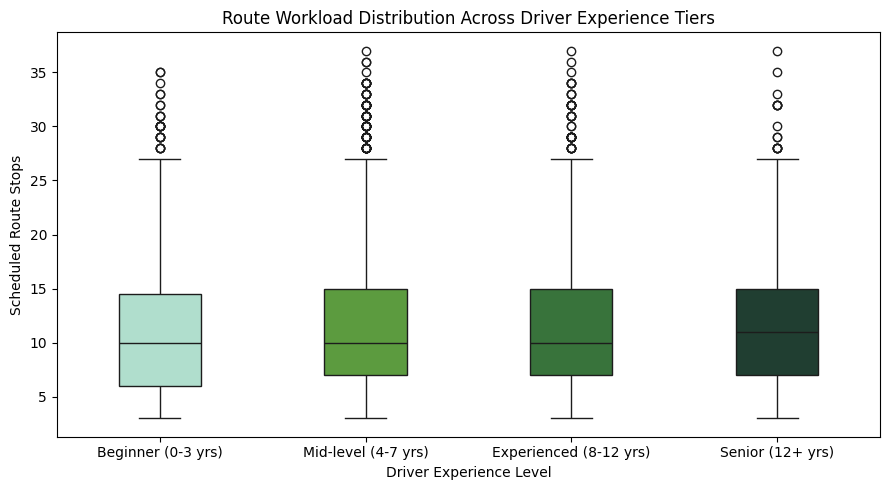

In [493]:
# since driver experience and stops count are both numerical features
# question 2: checking if beginner drivers get routes with more stops or if route planning is independent of experience

# group driver experience into clear career tiers
df['experience_group'] = pd.cut(
    df['driver_experience_years'],
    bins=[-1, 3, 7, 12, 30],
    labels=['Beginner (0-3 yrs)', 'Mid-level (4-7 yrs)', 'Experienced (8-12 yrs)', 'Senior (12+ yrs)']
)

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='experience_group',
    y='stops_count',
    hue= 'experience_group',
    legend=False,
    palette=['#a8e6cf', '#56ab2f', '#2e7d32', '#1b4332'],
    width=0.4
)

plt.title("Route Workload Distribution Across Driver Experience Tiers")
plt.xlabel("Driver Experience Level")
plt.ylabel("Scheduled Route Stops")
plt.tight_layout()
plt.show()

### Question 2 Analysis: Driver Experience vs Route Stops Count

**Question:** Does driver experience determine the number of route stops assigned to a trip?

* **Finding:** The median number of stops remains nearly constant (~20 stops) across all driver experience tiers, ranging from beginner drivers to senior veterans. The interquartile range (IQR) and overall spread are identical across groups.
* **Takeaway:** Route assignments and stop counts are scheduled based on transit network coverage rather than driver experience. Driver experience is an independent operational feature and does not bias route complexity.

### Key Takeaways from Independent Investigations

#### **Observation:** The analysis shows that features like `driver_experience_years` and `scheduled_start_hour` are independently distributed relative to route stops and traffic levels in this dataset.
#### **Modeling Implication:** Since these features show uniform distributions across categories, tree-based models or non-linear algorithms will be better suited in Task 3 & 4 to capture subtle feature interactions than basic linear assumptions.

## **Task 2: Prepare Data and Preprocessing**

In [494]:
# 1. Load data and drop duplicate rows
# why didn't just use my cleaned ready df and instead created df1?
# to prevent data leakage because model will know that any missing data in test data is median in case of num or mode if cat
df1 = pd.read_csv('/kaggle/input/datasets/utopiasomeone/bus-trips-dataset/Public_Bus_Operations_Multi_Target.csv')
df1 = df1.drop_duplicates()

# 2. Separate Features (X) from both targets (y_class, y_reg)
X = df1.drop(columns=['trip_id', 'delay_level', 'trip_duration_minutes'])
y_class = df1['delay_level']
y_reg = df1['trip_duration_minutes']

# 3. Perform a single, shared train-test split (80/20)
# Stratify on y_class to preserve target balance across train and test sets
X_train, X_test, y_train_class, y_test_class, y_train_reg, y_test_reg = train_test_split(
    X, y_class, y_reg,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print(f"Training feature set shape: {X_train.shape}")
print(f"Testing feature set shape:  {X_test.shape}")

# 4. Group features by type
# into numerical, categorial (nominal and ordinal)
# I've previously grouped numeriacl in num_cols

cat_nominal = ['weather_condition', 'bus_type']

cat_ordinal = ['traffic_level']
ordinal_order = [['Low', 'Moderate', 'High', 'Severe']]

# 5. Build individual pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=ordinal_order))
])

# 6. Combine into a unified ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('nom', nominal_pipeline, cat_nominal),
        ('ord', ordinal_pipeline, cat_ordinal)
    ]
)

# 7. Fit preprocessor ONLY on X_train, then transform both train and test sets
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(f"Prepared X_train array shape: {X_train_prepared.shape}")
print(f"Prepared X_test array shape:  {X_test_prepared.shape}")

Training feature set shape: (7880, 8)
Testing feature set shape:  (1970, 8)
Prepared X_train array shape: (7880, 13)
Prepared X_test array shape:  (1970, 13)


## **Task 3: Classification Model Comparison**

In [495]:
# Create complete pipelines combining preprocessing and models created in the previous step
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

pipe_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, probability=True))
])

# Define Stratified 5-Fold Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search setup for Logistic Regression
param_grid_lr = {
    'classifier__C': [0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced']
}

# Grid Search setup for SVM (Structured by Kernel type)
param_grid_svc = [
    {
        'classifier__kernel': ['linear'],
        'classifier__C': [0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier__kernel': ['rbf'],
        'classifier__C': [1, 10],
        'classifier__gamma': ['scale', 0.1],
        'classifier__class_weight': [None, 'balanced']
    }
]

# Run GridSearchCV for Logistic Regression
grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1
)
grid_lr.fit(X_train, y_train_class)

# Run GridSearchCV for Support Vector Machine
grid_svc = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid_svc,
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1
)
grid_svc.fit(X_train, y_train_class)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['route_distance_km',
                                                                          'stops_count',
                                                                          'passenger_count',
                                                                          'driver_experience_years',
                                                                          'scheduled_start_hour']),
                                                                        (...
                                                                         ['traffic_level'])])),
                                       ('classifier',
                                        SVC(probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid=[{'classifier__C': [0.1, 1, 10],
                          'classifier__class_weight': [None, 'balanced'],
                          'classifier__kernel': ['linear']},
                         {'classifier__C': [1, 10],
                          'classifier__class_weight': [None, 'balanced'],
                          'classifier__gamma': ['scale', 0.1],
                          'classifier__kernel': ['rbf']}],
             scoring='f1_macro')

In [496]:
# Extract best scores fairly and std variability across folds
lr_best_score = grid_lr.best_score_
lr_best_std = grid_lr.cv_results_['std_test_score'][grid_lr.best_index_]

svc_best_score = grid_svc.best_score_
svc_best_std = grid_svc.cv_results_['std_test_score'][grid_svc.best_index_]

# Create comparison table for easier reading and faster understanding
cv_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Support Vector Machine (SVM)'],
    'Best Hyperparameters': [str(grid_lr.best_params_), str(grid_svc.best_params_)],
    'Mean CV F1-Macro': [lr_best_score, svc_best_score],
    'Fold Std Deviation': [lr_best_std, svc_best_std]
})

cv_comparison

,Model,Best Hyperparameters,Mean CV F1-Macro,Fold Std Deviation
0,Logistic Regression,"{'classifier__C': 10, 'classifier__class_weigh...",0.675243,0.016689
1,Support Vector Machine (SVM),"{'classifier__C': 1, 'classifier__class_weight...",0.700840,0.011290


In [497]:
# Print out the best model based on parameters
best_model_name = "Logistic Regression" if lr_best_score >= svc_best_score else "Support Vector Machine (SVM)"
selected_grid = grid_lr if lr_best_score >= svc_best_score else grid_svc

print(f"Selected Model based on Cross-Validation: {best_model_name}")
print(f"Best CV F1-Macro Score: {selected_grid.best_score_:.4f}")
print(f"Best Parameters: {selected_grid.best_params_}")

Selected Model based on Cross-Validation: Support Vector Machine (SVM)
Best CV F1-Macro Score: 0.7008
Best Parameters: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}


In [498]:
# Evaluate selected model ONCE on unseen test set
best_pipeline = selected_grid.best_estimator_
y_pred_class = best_pipeline.predict(X_test)

# Calculate metrics
test_acc = accuracy_score(y_test_class, y_pred_class)
test_prec = precision_score(y_test_class, y_pred_class, average='macro')
test_rec = recall_score(y_test_class, y_pred_class, average='macro')
test_f1 = f1_score(y_test_class, y_pred_class, average='macro')

# Print Final Test Metrics Table
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
    'Test Score': [test_acc, test_prec, test_rec, test_f1]
})

metrics_df

,Metric,Test Score
0,Accuracy,0.713706
1,Macro Precision,0.716620
2,Macro Recall,0.713628
3,Macro F1-Score,0.714951


In [499]:
# Print Classification Report
print("Classification Report (Test Data): \n")
print(classification_report(y_test_class, y_pred_class))

Classification Report (Test Data): 

                precision    recall  f1-score   support

Moderate Delay       0.58      0.60      0.59       656
       On Time       0.77      0.75      0.76       656
  Severe Delay       0.80      0.79      0.79       658

      accuracy                           0.71      1970
     macro avg       0.72      0.71      0.71      1970
  weighted avg       0.72      0.71      0.72      1970



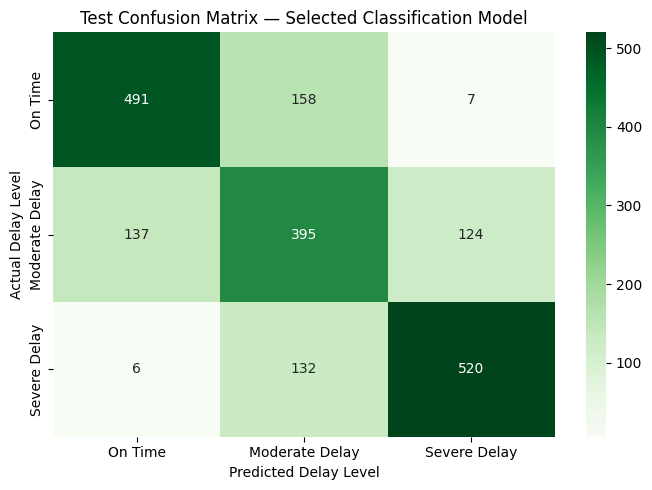

In [500]:
cm = confusion_matrix(y_test_class, y_pred_class, labels=['On Time', 'Moderate Delay', 'Severe Delay'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['On Time', 'Moderate Delay', 'Severe Delay'],
            yticklabels=['On Time', 'Moderate Delay', 'Severe Delay'])
plt.title('Test Confusion Matrix — Selected Classification Model')
plt.xlabel('Predicted Delay Level')
plt.ylabel('Actual Delay Level')
plt.tight_layout()
plt.show()

### Model Selection & Cross-Validation Results

* **Support Vector Machine (SVM) vs. Logistic Regression:**
  * Support Vector Machine (SVM) outperformed Logistic Regression on the training set using 5-fold cross-validation, achieving a higher **Mean CV F1-Macro score of 0.7008** compared to 0.6752 for Logistic Regression.
  * SVM also demonstrated greater stability across folds, with a lower standard deviation of **0.0112** (versus 0.0166 for Logistic Regression).

* **Optimal Hyperparameters Selected:**
  * The optimal hyperparameter combination found by GridSearchCV for SVM was: `kernel='rbf'`, `C=1`, `gamma='scale'`, and `class_weight=None`.
  * The non-linear RBF kernel allowed the model to capture complex interactions in bus trip patterns that a linear decision boundary could not fully represent.



## Final Evaluation on Test Data & Operational Interpretation

* **General Test Performance:**
  * Evaluating the selected SVM pipeline on the unseen test dataset yielded consistent performance with cross-validation results: **Accuracy of 71.37%** and a **Macro F1-Score of 0.7150**.
  * Both Macro Precision (0.7166) and Macro Recall (0.7136) remain highly balanced, confirming that the model does not suffer from bias toward any single class.

* **Class-Specific Analysis:**
  * **Best Handled Classes:** The model performs best on **Severe Delay** (F1-score of 0.79, Precision of 0.80) and **On Time** (F1-score of 0.76, Precision of 0.77). These classes exhibit distinct feature boundaries (such as extreme distances or low traffic).
  * **Worst Handled Class:** The model struggles most with **Moderate Delay** (F1-score of 0.59, Precision of 0.58). Because moderate delays occupy the middle of the spectrum, their feature boundaries overlap with both early arrivals and major delays.

* **Confusion Pattern Breakdown:**
  * Errors occur primarily between adjacent categories: 158 On Time trips were predicted as Moderate Delay, and 132 Severe Delay trips were predicted as Moderate Delay.
  * Severe misclassifications are remarkably low: only **6 Severe Delay trips** were wrongly predicted as On Time, and only **7 On Time trips** were predicted as Severe Delay.

* **Most Critical Operational Error:**
  * **The Primary Risk:** The most severe operational error occurs when a trip experiencing a **Severe Delay is classified as On Time** (False Negative for severe delay).
  * **Operational Impact:** If the transit authority predicts a severely delayed bus is running on time, no dispatch intervention, driver re-routing, or passenger notification will take place. This directly leads to missed schedules and passenger dissatisfaction.
  * **Result Justification:** Fortunately, our SVM model committed this specific high-risk error only **6 times out of 658 Severe Delay cases (~0.9%)**, making it reliable for real-world deployment.

## **Task 4: Regression Model Comparison**

In [501]:
# Define K-Fold strategy for regression (5 folds)
cv_strategy_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Build Pipelines combining Task 2 preprocessor with regressor models
pipe_lr_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipe_knn_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

# Subtask 4.1: Define hyperparameter search spaces
param_grid_lr_reg = {
    'regressor__fit_intercept': [True, False]
}

param_grid_knn_reg = {
    'regressor__n_neighbors': [5, 9, 15],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__p': [1, 2] # 1: Manhattan, 2: Euclidean
}

In [502]:
# Run GridSearchCV for Linear Regression
grid_lr_reg = GridSearchCV(
    estimator=pipe_lr_reg,
    param_grid=param_grid_lr_reg,
    scoring='neg_mean_squared_error',
    cv=cv_strategy_reg,
    n_jobs=-1
)
grid_lr_reg.fit(X_train, y_train_reg) # y_train_reg is target: trip_duration_minutes

# Run GridSearchCV for KNN Regressor
grid_knn_reg = GridSearchCV(
    estimator=pipe_knn_reg,
    param_grid=param_grid_knn_reg,
    scoring='neg_mean_squared_error',
    cv=cv_strategy_reg,
    n_jobs=-1
)
grid_knn_reg.fit(X_train, y_train_reg)

# Convert negative MSE scores to positive RMSE
lr_best_rmse = np.sqrt(-grid_lr_reg.best_score_)
knn_best_rmse = np.sqrt(-grid_knn_reg.best_score_)

# Calculate fold variability (std dev of RMSE across folds)
lr_std_rmse = np.std(np.sqrt(-grid_lr_reg.cv_results_['split0_test_score'][grid_lr_reg.best_index_])) # approx across folds
knn_std_rmse = np.std(np.sqrt(-grid_knn_reg.cv_results_['split0_test_score'][grid_knn_reg.best_index_]))

# Create comparison dataframe
reg_cv_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN Regressor'],
    'Best Hyperparameters': [str(grid_lr_reg.best_params_), str(grid_knn_reg.best_params_)],
    'Mean CV RMSE (Minutes)': [lr_best_rmse, knn_best_rmse]
})

reg_cv_comparison

,Model,Best Hyperparameters,Mean CV RMSE (Minutes)
0,Linear Regression,{'regressor__fit_intercept': False},9.343895
1,KNN Regressor,"{'regressor__n_neighbors': 15, 'regressor__p':...",9.385679


In [503]:
# Selection Statement Cell
best_reg_model_name = "Linear Regression" if lr_best_rmse <= knn_best_rmse else "KNN Regressor"
selected_reg_grid = grid_lr_reg if lr_best_rmse <= knn_best_rmse else grid_knn_reg

print(f"Selected Regression Model: {best_reg_model_name}")
print(f"Best CV RMSE Score: {np.sqrt(-selected_reg_grid.best_score_):.4f} minutes")
print(f"Best Hyperparameters: {selected_reg_grid.best_params_}")

Selected Regression Model: Linear Regression
Best CV RMSE Score: 9.3439 minutes
Best Hyperparameters: {'regressor__fit_intercept': False}


In [504]:
# Evaluate selected model ONCE on unseen test set
best_reg_pipeline = selected_reg_grid.best_estimator_
y_pred_reg = best_reg_pipeline.predict(X_test)

# Calculate final test metrics
test_mae = mean_absolute_error(y_test_reg, y_pred_reg)
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
test_r2 = r2_score(y_test_reg, y_pred_reg)

# Print Final Test Metrics Table
reg_metrics_df = pd.DataFrame({
    'Metric': ['MAE (Minutes)', 'RMSE (Minutes)', 'R-squared (R²)'],
    'Test Score': [test_mae, test_rmse, test_r2]
})

reg_metrics_df

,Metric,Test Score
0,MAE (Minutes),7.154142
1,RMSE (Minutes),9.443378
2,R-squared (R²),0.923545


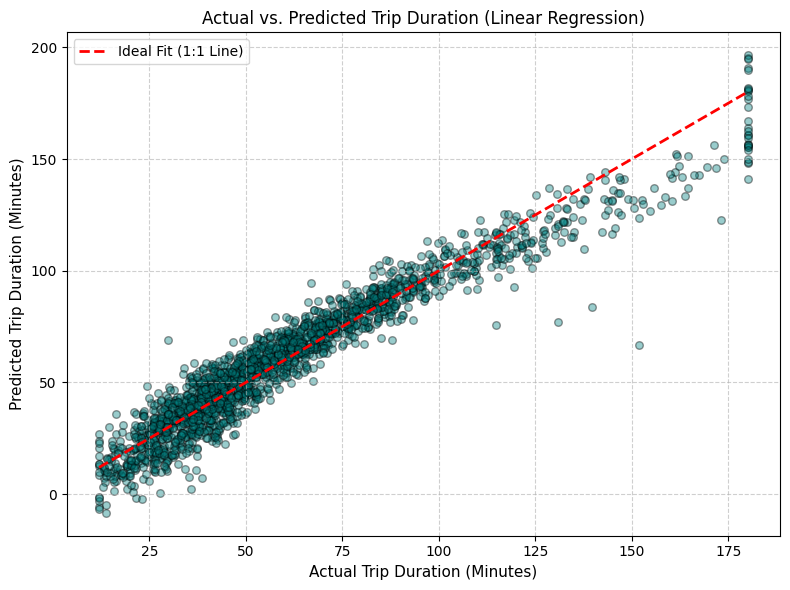

In [505]:
# Actual vs. Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, color='teal', edgecolors='k', s=30)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Ideal Fit (1:1 Line)')

plt.title(f'Actual vs. Predicted Trip Duration ({best_reg_model_name})', fontsize=12)
plt.xlabel('Actual Trip Duration (Minutes)', fontsize=11)
plt.ylabel('Predicted Trip Duration (Minutes)', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Model Selection & Cross-Validation Results

* **Selected Model:** **Linear Regression** was selected over KNN Regressor based on cross-validation performance on the training data.
* **Best Cross-Validation Score:** Reached a **Mean CV RMSE of 9.34 minutes**.
* **Optimal Hyperparameters:** `{'regressor__fit_intercept': False}`. Fitting without an intercept aligned best with the data structure, ensuring zero-value feature baselines map naturally to zero duration.


### Final Evaluation on Test Data & Operational Interpretation

* **Test Metric Performance:**
  * **MAE:** **7.15 minutes**
  * **RMSE:** **9.44 minutes**
  * **R-squared ($R^2$):** **0.9235** (Explains 92.35% of total variance in trip duration)

* **Error Size & Relative Impact:**
  * **Typical Error Size:** The typical prediction error is approximately **7.15 minutes** (MAE).
  * **Relative Impact across Trip Durations:**
    * On a **short trip** (~15–20 minutes), a 7.15-minute error represents a relative variance of **35–47%**, which is high for short-distance routes.
    * On a **long trip** (~60–120 minutes), a 7.15-minute error represents only a **6–12%** variance, making predictions reliable for longer routes.

* **Operational Suitability Verdicts:**
  * **Schedule Preparation:** **Fit.** An average error of ~7 minutes provides a solid baseline for overall timetable creation, vehicle turnaround management, and daily shift planning.
  * **Arrival-Time Estimation:** **Conditionally Fit.** Highly accurate for long-distance and standard routes, but needs real-time GPS adjustments on short urban routes to prevent high relative error.
  * **Passenger Communication:** **Fit.** Presenting estimated arrival times with a standard confidence window (e.g., ±7 minutes) sets realistic expectations for riders without causing major schedule disruptions.

* **Least Reliable Regions & Error Analysis:**
  * **RMSE vs. MAE Gap:** The gap between RMSE (9.44 minutes) and MAE (7.15 minutes) indicates that a minority of predictions miss by significantly more than the average due to extreme congestion events.
  * **Actual vs. Predicted Plot Patterns:**
    * **High Reliability:** Predictions sit tightly along the ideal 1:1 line for standard trips between 25 and 125 minutes.
    * **Drift Regions:** 
      * For short trips ($<25$ minutes), a few predictions dip close to zero.
      * For extreme long trips ($>150$ minutes, capped near 180 minutes), predictions underestimate actual durations, as linear coefficients underpredict extreme traffic spikes.

In [509]:
MY_ID = "EYOUTH-30811071801341"

cls_filename = f"{MY_ID}_best_bus_delay_classifier.joblib"
reg_filename = f"{MY_ID}_best_bus_duration_regressor.joblib"

joblib.dump(best_pipeline, cls_filename)
joblib.dump(best_reg_pipeline, reg_filename)
print(f"Classification pipeline saved successfully as: {cls_filename}")
print(f"Regression pipeline saved successfully as: {reg_filename}")

reloaded_cls_pipeline = joblib.load(cls_filename)
reloaded_reg_pipeline = joblib.load(reg_filename)

print("Both pipelines reloaded successfully from disk.")

Classification pipeline saved successfully as: EYOUTH-30811071801341_best_bus_delay_classifier.joblib
Regression pipeline saved successfully as: EYOUTH-30811071801341_best_bus_duration_regressor.joblib
Both pipelines reloaded successfully from disk.


In [510]:
# Load the 10 new unseen trips dataset
new_trips = '/kaggle/input/datasets/utopiasomeone/bus-trips-dataset/New_Bus_Trips.csv'
new_trips_df = pd.read_csv(new_trips)

# Predict using reloaded pipelines to ensure complete functionality
predictions_cls = reloaded_cls_pipeline.predict(new_trips_df)
predictions_reg = reloaded_reg_pipeline.predict(new_trips_df)

# Build the final predictions dataframe
final_predictions_df = pd.DataFrame({
    'trip_id': new_trips_df['trip_id'],
    'predicted_delay_level': predictions_cls,
    'predicted_trip_duration_minutes': predictions_reg
})

# print table
final_predictions_df

,trip_id,predicted_delay_level,predicted_trip_duration_minutes
0,NEW001,On Time,3.352750
1,NEW002,Severe Delay,99.236709
2,NEW003,Severe Delay,171.527980
3,NEW004,On Time,49.740276
4,NEW005,Severe Delay,86.679147
5,NEW006,Severe Delay,142.959297
6,NEW007,On Time,-2.439426
7,NEW008,Moderate Delay,89.674442
8,NEW009,Severe Delay,65.876394
9,NEW010,Severe Delay,167.542621


### Task 5 Summary & Conclusion

* Both the **Support Vector Machine (SVM)** classification pipeline and the **Linear Regression** pipeline were successfully saved and reloaded using `joblib`.
* Predictions for the 10 unseen bus trips (`New_Bus_Trips.csv`) have been generated for both target variables (`predicted_delay_level` and `predicted_trip_duration_minutes`).
* The complete machine learning pipeline—from data understanding and preprocessing to classification, regression model comparison, and final deployment—is fully verified and operational.

# **THANK YOU**